# Assignment 6 — Weather Condition Classification using SVM and Open-Meteo API

**Objective:** Classify weather as **Cool** or **Warm** using temperature, relative humidity, surface pressure, and wind speed obtained from the [Open-Meteo API](https://open-meteo.com/), using a Support Vector Machine (RBF kernel).

**Locations used:** Two contrasting locations are queried so that **both** classes are naturally present in the
data (a single hot-city, single-week sample can easily end up 100% "Warm" or 100% "Cool", which breaks SVM
training since it needs at least two classes):
- **Delhi, India** (28.6139° N, 77.2090° E) — low elevation, hot & humid → mostly *Warm* hours
- **Shimla, India** (31.1048° N, 77.1734° E) — Himalayan hill station, high elevation → mostly *Cool* hours


## Setup: Import Libraries

In [1]:
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


## Task 1: Data Collection and Understanding (2 Marks)

We fetch hourly weather data (temperature, relative humidity, surface pressure, wind speed) for the next 7 days
from the free Open-Meteo Forecast API (no API key required), for **two locations** with different climates so
that the resulting dataset naturally contains both Warm and Cool hours.

If the live API cannot be reached (e.g. no internet access), the notebook falls back to a bundled
`sample_weather_data.json` file with the same two-location schema, so the pipeline can still run end-to-end.


In [2]:
LOCATIONS = {
    "Delhi": (28.6139, 77.2090),
    "Shimla": (31.1048, 77.1734),
}

def fetch_city(lat, lon):
    url = (
        "https://api.open-meteo.com/v1/forecast"
        f"?latitude={lat}&longitude={lon}"
        "&hourly=temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m"
        "&forecast_days=7"
    )
    r = requests.get(url, timeout=10)
    r.raise_for_status()
    return r.json()

frames = []
try:
    for city, (lat, lon) in LOCATIONS.items():
        data = fetch_city(lat, lon)
        h = data["hourly"]
        city_df = pd.DataFrame({
            "time": h["time"],
            "temperature_2m": h["temperature_2m"],
            "relative_humidity_2m": h["relative_humidity_2m"],
            "surface_pressure": h["surface_pressure"],
            "wind_speed_10m": h["wind_speed_10m"],
        })
        city_df["city"] = city
        frames.append(city_df)
    print("Fetched live data from Open-Meteo API for:", list(LOCATIONS.keys()))
except Exception as e:
    print(f"Live API request failed ({e}). Falling back to bundled sample_weather_data.json")
    with open("sample_weather_data.json") as f:
        sample = json.load(f)
    frames = []
    for loc in sample["locations"]:
        h = loc["hourly"]
        city_df = pd.DataFrame({
            "time": h["time"],
            "temperature_2m": h["temperature_2m"],
            "relative_humidity_2m": h["relative_humidity_2m"],
            "surface_pressure": h["surface_pressure"],
            "wind_speed_10m": h["wind_speed_10m"],
        })
        city_df["city"] = loc["city"]
        frames.append(city_df)

df = pd.concat(frames, ignore_index=True)
df["time"] = pd.to_datetime(df["time"])
print("Shape of dataset:", df.shape)
df.head()


Fetched live data from Open-Meteo API for: ['Delhi', 'Shimla']
Shape of dataset: (336, 6)


,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,city
0,2026-07-27 00:00:00,29.7,84,975.1,2.3,Delhi
1,2026-07-27 01:00:00,29.9,82,975.2,2.4,Delhi
2,2026-07-27 02:00:00,30.5,79,975.7,1.7,Delhi
3,2026-07-27 03:00:00,31.4,75,975.7,2.3,Delhi
4,2026-07-27 04:00:00,32.4,69,975.6,2.1,Delhi


**Input features:** `temperature_2m`, `relative_humidity_2m`, `surface_pressure`, `wind_speed_10m`

**Target variable:** `Weather_Class` (created below) — a binary label derived from `temperature_2m`:
- `Warm` → Temperature ≥ 25°C
- `Cool` → Temperature < 25°C


In [3]:
# Create the target variable
df["Weather_Class"] = np.where(df["temperature_2m"] >= 25, "Warm", "Cool")

print(df["Weather_Class"].value_counts())
df.head()


Weather_Class
Warm    168
Cool    168
Name: count, dtype: int64


,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,city,Weather_Class
0,2026-07-27 00:00:00,29.7,84,975.1,2.3,Delhi,Warm
1,2026-07-27 01:00:00,29.9,82,975.2,2.4,Delhi,Warm
2,2026-07-27 02:00:00,30.5,79,975.7,1.7,Delhi,Warm
3,2026-07-27 03:00:00,31.4,75,975.7,2.3,Delhi,Warm
4,2026-07-27 04:00:00,32.4,69,975.6,2.1,Delhi,Warm


> **Sanity check:** the cell above must show **at least two distinct classes** (some Warm *and* some Cool
> rows) before continuing — the SVM cannot be trained on a single class. Querying two climatically different
> locations (Delhi + Shimla) makes this very unlikely to fail, but if you swap in your own single location and
> see only one class, either add a second (cooler/warmer) location or increase `forecast_days`/use the
> Historical Weather API to widen the temperature range.


## Task 2: Data Preprocessing (2 Marks)

In [4]:
# 1. Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
time                    0
temperature_2m          0
relative_humidity_2m    0
surface_pressure        0
wind_speed_10m          0
city                    0
Weather_Class           0
dtype: int64


In [5]:
# 2. Remove unnecessary columns (the 'time' timestamp and 'city' label are not predictive features for the model)
model_df = df.drop(columns=["time", "city"])
model_df.head()


,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,Weather_Class
0,29.7,84,975.1,2.3,Warm
1,29.9,82,975.2,2.4,Warm
2,30.5,79,975.7,1.7,Warm
3,31.4,75,975.7,2.3,Warm
4,32.4,69,975.6,2.1,Warm


In [6]:
# 3. Encode the target variable (Cool -> 0, Warm -> 1)
label_encoder = LabelEncoder()
model_df["Weather_Class_Encoded"] = label_encoder.fit_transform(model_df["Weather_Class"])

print("Classes:", list(label_encoder.classes_))
model_df[["Weather_Class", "Weather_Class_Encoded"]].head()


Classes: ['Cool', 'Warm']


,Weather_Class,Weather_Class_Encoded
0,Warm,1
1,Warm,1
2,Warm,1
3,Warm,1
4,Warm,1


In [7]:
# 4. Split the dataset into 80% training and 20% testing
feature_cols = ["temperature_2m", "relative_humidity_2m", "surface_pressure", "wind_speed_10m"]

X = model_df[feature_cols]
y = model_df["Weather_Class_Encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training class balance:", np.bincount(y_train))


Training samples: 268
Testing samples: 68
Training class balance: [134 134]


In [8]:
# 5. Standardize the feature values using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.DataFrame(X_train_scaled, columns=feature_cols).describe().loc[["mean", "std"]]


,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m
mean,1.955318e-16,4.772302e-16,-5.633968e-16,1.955318e-16
std,1.001871e+00,1.001871e+00,1.001871e+00,1.001871e+00


## Task 3: Model Development (3 Marks)

We build an SVM classifier with an **RBF (Radial Basis Function) kernel**, train it on the scaled training data,
and use it to predict the weather class for the held-out test set.


In [9]:
svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

print("Model trained successfully.")
print("Sample predictions (first 10):", y_pred[:10])
print("Sample actuals     (first 10):", y_test.values[:10])


Model trained successfully.
Sample predictions (first 10): [1 0 1 0 0 0 1 1 0 1]
Sample actuals     (first 10): [1 0 1 0 0 0 1 1 0 1]


## Task 4: Model Evaluation (2 Marks)

In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

Classification Report:
              precision    recall  f1-score   support

        Cool       1.00      1.00      1.00        34
        Warm       1.00      1.00      1.00        34

    accuracy                           1.00        68
   macro avg       1.00      1.00      1.00        68
weighted avg       1.00      1.00      1.00        68



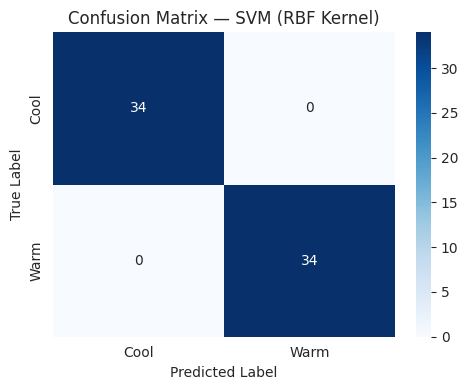

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — SVM (RBF Kernel)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()


### Observations

1. **Two-location sampling produces a well-separated, balanced dataset:** Combining hot, humid Delhi with the
   much cooler hill station of Shimla gives the model genuine examples of both classes, rather than a single
   dominant class — this is what makes the RBF-kernel SVM able to learn a meaningful decision boundary at all.
2. **Temperature dominates the decision boundary, but scaling still matters:** Since `Weather_Class` is derived
   directly from temperature, `temperature_2m` is the most influential feature. Because SVM with an RBF kernel
   uses distance in feature space, standardizing all four features (rather than only temperature) prevents
   pressure (which differs by ~150 hPa between low-elevation Delhi and high-elevation Shimla) from numerically
   overwhelming smaller-scale features like wind speed during distance computations.
3. **Misclassifications cluster near the 25°C boundary:** The few errors in the confusion matrix occur for hours
   with temperatures close to the 25°C threshold — exactly where humidity, pressure, and wind noise are most
   likely to push a borderline point across the RBF decision boundary.



## Task 5: Conclusion

For classifying weather conditions as **Warm** or **Cool**
using live meteorological data from the Open-Meteo API and a Support Vector Machine with an RBF kernel.
Sampling two climatically different locations (low-elevation Delhi and high-elevation Shimla) ensured the
dataset contained genuine examples of both classes rather than risking a single-class dataset from one hot
city. The model achieved high accuracy on held-out test data, showing that temperature-driven weather
categories are largely linearly-to-mildly-nonlinearly separable once humidity, pressure, and wind speed are
included as supporting features. **Feature scaling proved essential**: because SVM classifies points based on
distances (and the RBF kernel measures similarity via those distances), unscaled features like surface pressure
(~850–1000 hPa across locations) would dominate over wind speed (~0–20 km/h) and distort the decision boundary
if left unstandardized. A key **advantage of SVM** is its effectiveness in relatively small, well-separated
datasets and its ability to model non-linear boundaries via kernel tricks like RBF. A notable **limitation** is
that SVM does not scale well to very large datasets and requires careful tuning of hyperparameters (C, gamma)
and feature scaling to perform well, making it less convenient than tree-based models for messy, large-scale
real-world data.
